In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import uproot
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

# Load in the Run 1-3 data

In [17]:
#RUN = ["1"]
RUN = ["1","2","3"]

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data="bnb",
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=False,
    load_lee=False,
    load_nue_tki=True,
    blinded=True,
    load_crt_vars=False,
    enable_cache=True,
)

Loading run 1
Loading run 2
Loading run 3


In [18]:
print("category_1e1p" in rundata["mc"].columns)

True


# Prepare the MC for use in comparisons

Make a unique identifer using the run, subrun and event numbers for easy comparison later on

In [4]:
def make_unique_ev_id(df): #df must have 'run', 'sub' and 'evt' branches
    if pd.Series(['run', 'sub', 'evt']).isin(df.columns).all():
        rse_list = []
        for entry in df.index: #Looping over all events in the dataframe
            rse = str(df['run'][entry]) + "_" + str(df['sub'][entry]) + "_" + str(df['evt'][entry])
            rse_list.append(rse)
        df['rse_id'] = rse_list #Writing a new branch with the unique event id
        return df #.copy()
    else:
        print("Dataframe needs \"run\", \"sub\" and \"evt\" columns.")
        return 0
mc = rundata["mc"].reset_index(drop=True)
mc = make_unique_ev_id(mc)
mc.head()

,shr_id,mcf_np0,mcf_pass_nccpi,secondshower_Y_dir,true_nu_vtx_x,knobThetaDelta2Npiup,_opfilter_pe_beam,shr_px,category,slclustfrac,...,dz,dr,paper_category,paper_category_xsec,paper_category_numu,category_1e1p,dataset,weights,weights_no_tune,rse_id
0,3,0,0,9.227432,40.468273,1.036078,3449.309326,-0.055492,2,0.532207,...,-0.143097,0.211768,2,2,2,2,mc,0.130186,0.130186,5151_107_5392
1,3,0,0,48.215946,102.278618,2.184649,2692.645996,-0.060522,2,0.496383,...,0.135254,0.170766,2,2,2,2,mc,0.130186,0.130186,5151_80_4031
2,1,1,0,170.286133,48.042450,1.000000,5109.726074,0.000010,21,0.884740,...,-0.838928,0.853762,31,31,2,21,mc,0.130186,0.130186,5151_80_4048
3,1,1,0,96.146828,123.381386,1.060467,1398.026001,0.232230,21,0.649798,...,0.057831,0.681040,31,31,2,21,mc,0.130186,0.130186,5151_100_5018
4,2,0,0,210.796280,85.313560,0.656184,3591.575195,0.031994,2,0.704663,...,-1.834167,2.179828,2,2,2,13,mc,0.130186,0.130186,5151_100_5040


Apply the old and new selection cuts

In [10]:
from microfit import selections as sel

selection = "OnePL"
preselection = "OneP"
query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
#print(query)
old_sel = mc.query(query, engine='python')
print('Old selection:', len(old_sel))

selection = "OnePL_new"
preselection = "OneP_new"
query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
#print(query)
new_sel = mc.query(query, engine='python')
print('New selection:', len(new_sel))

Old selection: 367
New selection: 507


Variables to use in investigation

In [10]:
truth_vars = ('rse_id','Signal_1e1p','Sel_1e1p','mc_pdg','nproton','TrueNProt','nelec','TrueNElec','mc_proton_p','TrueLeadProtonModMom','mc_electron_p','TrueElecModMom','npi0','TrueFSPi0','mc_pion_p','npion','TrueFSPions','HasNoMesons')
reco_vars = ('rse_id','Signal_1e1p','Sel_1e1p','n_tracks_contained','n_reco_tracks','n_showers_contained','n_reco_showers','RecoLeadProtonModMom','RecoElecModMom')
all_vars = truth_vars + reco_vars

# Look at signal events

In [19]:
# old_sig = old_sel['category_1e1p'] == 6
# old_sel_sig = old_sel.loc[old_sig]
# print('Old signal events', len(old_sel_sig))

# Plotting the distributions

Old selection

('RecoDeltaPT', 20, (0, 2), '$\\delta p_T$ [GeV/c]')


../../microfit/run_plotter.py:119: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


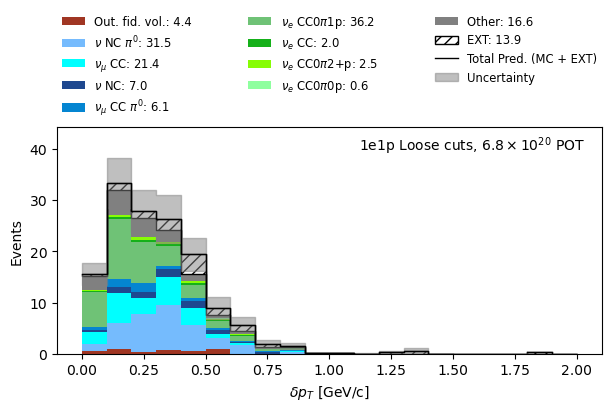

../../microfit/run_plotter.py:119: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


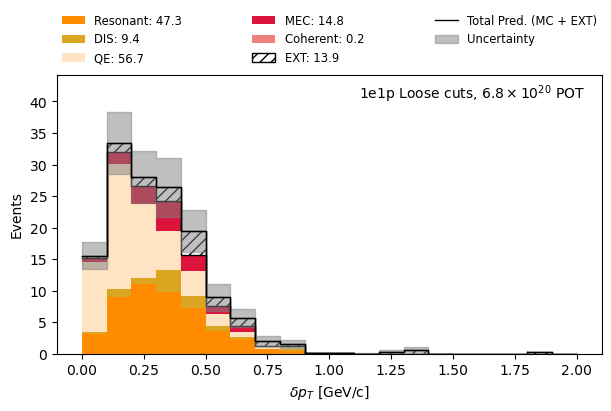

('RecoDeltaAlphaT', 20, (0, 180), '$\\delta \\alpha_T$ [degrees]')


../../microfit/run_plotter.py:119: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


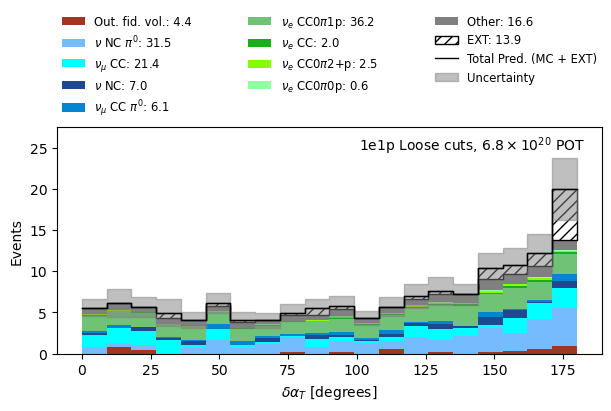

../../microfit/run_plotter.py:119: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


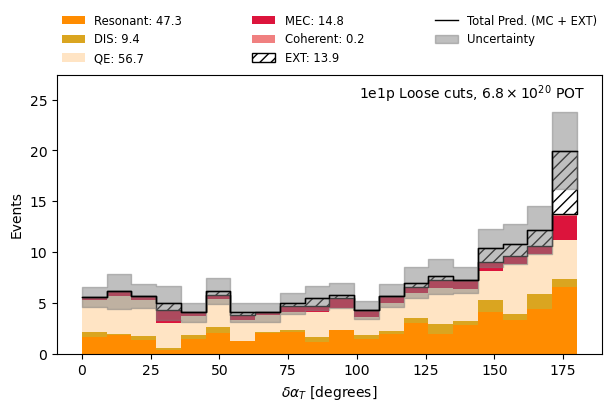

In [7]:
selection = "OnePL"
preselection = "OneP"

for binning_def in vdef.TKI_variables_1e1p:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    binning = hist.Binning.from_config(*binning_def[:4])
    print(binning_def)
    signal_generator = hist.RunHistGenerator(
        rundata,
        binning,
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
    )
    plotter = rp.RunHistPlotter(signal_generator)
    axes = plotter.plot(
        category_column="category_1e1p",
        include_multisim_errors=True,
        add_ext_error_floor=False,
        show_data_mc_ratio=False,
        show_chi_square=False,
    )
    
    plt.savefig(f'plots/investigation/topo_{preselection}_{selection}_{binning_def[0]}.pdf', bbox_inches='tight')
    plt.show()

    axes2 = plotter.plot(
        category_column="interaction",
        include_multisim_errors=True,
        add_ext_error_floor=False,
        show_data_mc_ratio=False,
        show_chi_square=False,
    )

    plt.savefig(f'plots/investigation/int_{preselection}_{selection}_{binning_def[0]}.pdf', bbox_inches='tight')
    plt.show()

# Misc

In [15]:
cosmic_old = mc['category_1e1p'] == 4
mc_cosmic_old = mc.loc[cosmic_old]
print(len(mc_cosmic_old))

0


In [56]:
cosmic_new = mc['category_1e1p_tki'] == 4
mc_cosmic_new = mc.loc[cosmic_new, all_vars]
print(len(mc_cosmic_new))
mc_cosmic_new.head(6)

6


,rse_id,Signal_1e1p,Sel_1e1p,mc_pdg,nproton,TrueNProt,nelec,TrueNElec,mc_proton_p,TrueLeadProtonModMom,...,HasNoMesons,rse_id,Signal_1e1p,Sel_1e1p,n_tracks_contained,n_reco_tracks,n_showers_contained,n_reco_showers,RecoLeadProtonModMom,RecoElecModMom
28113,7019_143_7151,False,True,"[-12, 2212, -211]",1,1,0,0,0.471934,0.471393,...,False,7019_143_7151,False,True,3,1,2,1,0.446919,0.244936
32504,10704_264_13227,False,False,"[-12, -211, 2212, 2212, 111]",1,1,0,0,1.681786,1.681634,...,False,10704_264_13227,False,False,1,0,3,3,NaN,0.317781
41239,9612_20_1040,False,True,"[-12, 2212, -211, -211, 2212, 111, 2212]",2,2,0,0,1.169048,1.168830,...,False,9612_20_1040,False,True,3,1,1,1,0.406931,0.108869
58773,18021_287_14376,False,False,"[-12, 22, 2212, 2212]",2,2,0,0,0.604891,0.604469,...,True,18021_287_14376,False,False,2,2,1,1,0.601033,0.353908
64182,16586_121_6089,False,False,"[-12, 2112, 2212, 2212, 2212]",3,3,0,0,0.509608,0.509107,...,True,16586_121_6089,False,False,1,0,1,1,NaN,0.100059
75367,16339_209_10464,False,False,"[-12, 2112, 2112, 111, 2212]",1,1,0,0,0.358423,0.357710,...,False,16339_209_10464,False,False,1,0,2,2,NaN,0.110554


In [19]:
other_old = mc['category_1e1p'] == 6
mc_other_old = mc.loc[other_old]
print(len(mc_other_old))

0


In [18]:
other_new = mc['category_1e1p_tki'] == 6
mc_other_new = mc.loc[other_new]
print(len(mc_other_new))

37361
